In [ ]:
#6
#Membuat kolom tambahan untuk day, month, month_num
df['day'] = df['order_date'].dt.day_name() #konversi tanggal ke hari
df['month'] = df['order_date'].dt.month_name() #konversi tanggal ke nama bulan
df['month_num'] = df['order_date'].dt.month #konversi tanggal ke bulan (dalam angka)
df['year'] = df['order_date'].dt.year #konversi tanggal ke tahun

df['ship_delay'] = df['ship_date'] - df['order_date'] #output: 2 days
df['ship_delay'] = df['ship_delay'].dt.days #output: 2
df.head()

In [ ]:
#4
#Menampilkan gambaran data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  subcategory    9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  sales          9994 non-null   float64
 18  quantity

## `Pastikan klik 'File > Save a copy in Drive' sebelum memulai pengerjaan`

# Pengaplikasian Python dalam Data Analysis

## Tujuan

Setelah menyelesaikan lab ini, kamu akan mampu untuk:
*   Mengunduh dataset dengan `file.download`
*   Pengelolaan data `date`
*   Penggunaan fungsi `groupby`
*   Membuat dan menggunakan fungsi sederhana pada `DataFrame`
*   Menggunakan `AI (Gemini)` untuk Data Analyst


In [ ]:
#1
#Mengimpor Libraries
import pandas as pd #import (nama package) as (singkatan)
import numpy as np
from google.colab import files #unggah dan unduh file

In [ ]:
#2
#Mengimpor dataset
URL = 'https://raw.githubusercontent.com/dataskillsboost/FinalProjectDA11/main/tokopaedi.csv'
df = pd.read_csv(URL)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,subcategory,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Menggunduh Dataset

In [ ]:
#3
#Mengunduh dataset
df.to_excel('df.xlsx') #convert ke table file (excel): .xlsx, .xls, .csv
files.download('df.xlsx') #download data to komputer/local

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#4
#Menampilkan gambaran data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  subcategory    9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  sales          9994 non-null   float64
 18  quantity

## Pengelolaan Data `Date`

In [ ]:
#5
#Mengubah tipe kolom Date menjadi Datetime
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  subcategory    9994 n

In [ ]:
#6
#Membuat kolom tambahan untuk day, month, month_num
df['day'] = df['order_date'].dt.day_name() #konversi tanggal ke hari
df['month'] = df['order_date'].dt.month_name() #konversi tanggal ke nama bulan
df['month_num'] = df['order_date'].dt.month #konversi tanggal ke bulan (dalam angka)
df['year'] = df['order_date'].dt.year #konversi tanggal ke tahun

df['ship_delay'] = df['ship_date'] - df['order_date'] #output: 2 days
df['ship_delay'] = df['ship_delay'].dt.days #output: 2
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_name,sales,quantity,discount,profit,day,month,month_num,year,ship_delay
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Tuesday,November,11,2016,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,Tuesday,November,11,2016,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Sunday,June,6,2016,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,Sunday,October,10,2015,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Sunday,October,10,2015,7


<p>Latihan: Filter berdasarkan bulan <code>October</code> tahun <code>2015</code>

In [ ]:
#7
#Filter berdasarkan bulan October tahun 2015
df_filtered = df[(df['month'] == 'October') & (df['year'] == 2015)]
df_filtered.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_name,sales,quantity,discount,profit,day,month,month_num,year,ship_delay
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,Sunday,October,10,2015,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Sunday,October,10,2015,7
109,110,CA-2015-129476,2015-10-15,2015-10-20,Standard Class,PA-19060,Pete Armstrong,Home Office,United States,Orland Park,...,Logitech Gaming G510s - Keyboard,339.9600,5,0.20,67.9920,Thursday,October,10,2015,5
189,190,CA-2015-102281,2015-10-12,2015-10-14,First Class,MP-17470,Mark Packer,Home Office,United States,New York City,...,"Atlantic Metals Mobile 4-Shelf Bookcases, Cust...",899.1360,4,0.20,112.3920,Monday,October,10,2015,2
190,191,CA-2015-102281,2015-10-12,2015-10-14,First Class,MP-17470,Mark Packer,Home Office,United States,New York City,...,I Need's 3d Hello Kitty Hybrid Silicone Case C...,71.7600,6,0.00,20.0928,Monday,October,10,2015,2


##Penggunaan fungsi `groupby`

### `groupby`

**Formula:**

nama variabel = nama_dataframe`.groupby(by=`['kolom_1'  ,   'kolom_2'])['kolom_agregasi']`.`jenis_agregasi()

Output: `series`


In [ ]:
#8
df_groupby = df.groupby(by=['month_num','month'])['profit'].sum()
df_groupby

In [ ]:
#9
#merubah output groupby menjadi DataFrame dengan as_index = False
df_groupby = df.groupby(by=["month_num","month"], as_index=False)["profit"].sum()
df_groupby

,month_num,month,profit
0,1,January,9134.4461
1,2,February,10294.6107
2,3,March,28594.6872
3,4,April,11587.4363
4,5,May,22411.3078
5,6,June,21285.7954
6,7,July,13832.6648
7,8,August,21776.9384
8,9,September,36857.4753
9,10,October,31784.0413


<p>Latihan: Buatlah dengan fungsi groupby, top 5 city penghasil profit paling besar

In [ ]:
#11 Latihan: Buatlah dengan fungsi groupby, top 5 city penghasil profit paling besar

df_city_profit = df.groupby('city')['profit'].sum().reset_index()
df_top_5_city = df_city_profit.sort_values(by='profit', ascending=False).head(5)
df_top_5_city

,city,profit
329,New York City,62036.9837
266,Los Angeles,30440.7579
452,Seattle,29156.0967
438,San Francisco,17507.3854
123,Detroit,13181.7908


In [ ]:
df_top_5_city.to_excel('5 top city.xlsx') #convert ke table file (excel): .xlsx, .xls, .csv
files.download('5 top city.xlsx') #download data to komputer/local

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Membuat dan menggunakan fungsi sederhana pada DataFrame

Formula:

`def` nama_fungsi `(`nilai`):`

    kondisi



In [ ]:
#12
#Membuat suatu fungsi
def condition(value):
    if value > 2:
      return 'High'
    elif value == 2:
      return 'Medium'
    else:
        return 'Low'

In [ ]:
#13
#Pengaplikasian fungsi
#buatkan kolom baru untuk mengaplikasikan fungsi yang sudah dibuat sebelum nya di #12
df['status'] = df['quantity'].apply(condition)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,day,month,month_num,year,ship_delay,status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,Tuesday,November,11,2016,3,Medium
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,Tuesday,November,11,2016,3,High
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,Sunday,June,6,2016,4,Medium
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,Sunday,October,10,2015,7,High
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,Sunday,October,10,2015,7,Medium


<p>Latihan: Buatlah suatu kolom baru yang bernama <code>ship_status</code> yang dapat menyatakan bahwa apabila waktu pengiriman <= 4 hari dari tanggal order maka <code>'Good'</code> selain itu maka <code>'Bad'</code>

In [ ]:
#14
#Buatlah suatu kolom baru yang bernama ship_status yang dapat menyatakan bahwa apabila waktu pengiriman <= 4 hari dari tanggal order maka 'Good' selain itu maka 'Bad'

def get_ship_status(delay):
    #jika delay <= 4 hari hasilnya good
    if delay <= 4:
        return 'Good'
    else:
        #jika delay > 4 hari hasilnya bad
        return 'Bad'

df['ship_status'] = df['ship_delay'].apply(get_ship_status)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,quantity,discount,profit,day,month,month_num,year,ship_delay,status,ship_status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,Tuesday,November,11,2016,3,Medium,Good
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,Tuesday,November,11,2016,3,High,Good
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,Sunday,June,6,2016,4,Medium,Good
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,Sunday,October,10,2015,7,High,Bad
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,Sunday,October,10,2015,7,Medium,Bad


<Axes: title={'center': 'Monthly Total Profit'}, xlabel='Month', ylabel='Total Profit'>

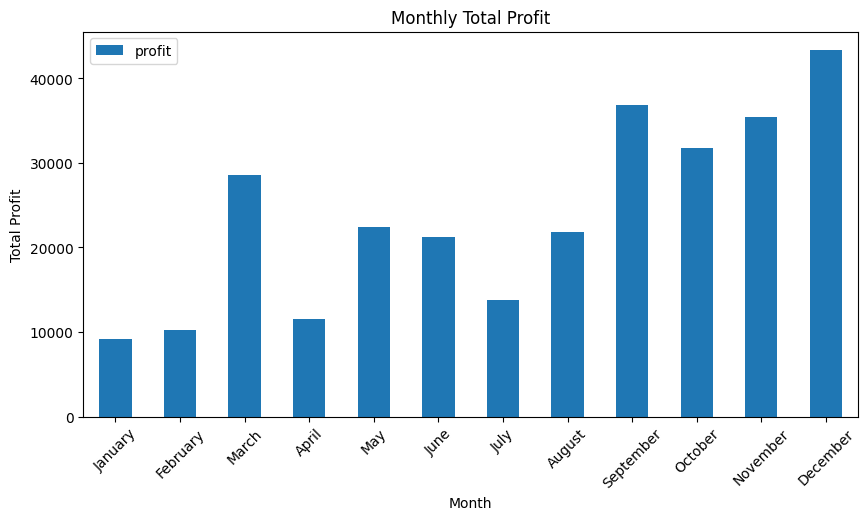

In [ ]:
#15
#Membuat grafik :
# agar tidak error harus di definisikan dulu dengan jalankan df_groupby seperti di point #9
df_groupby.plot(x='month',
           y='profit',
           kind='bar',
           grid = False,
           xlabel = 'Month',
           ylabel = 'Total Profit',
           figsize=(10,5),
           rot = 45, #Rotasi label x
           title = 'Monthly Total Profit')

## Menggunakan `AI (Gemini)` untuk Data Analyst


### Apa itu Gemini?
Gemini adalah model bahasa besar (Large Language Model/LLM) yang dikembangkan oleh Google. LLM seperti Gemini dilatih menggunakan dataset teks dan kode yang sangat besar, sehingga mereka mampu memahami, menghasilkan, dan memproses bahasa manusia dalam berbagai cara.


### Peran Gemini dalam Analisis Data
Dalam analisis data, Gemini dapat menjadi asisten yang sangat berguna, terutama bagi pemula. Beberapa perannya meliputi:


1. Menghasilkan Kode: Gemini dapat membantu menulis skrip Python untuk tugas-tugas umum analisis data, seperti memuat data, membersihkan data, melakukan perhitungan statistik, atau membuat visualisasi.
2. Menjelaskan Konsep: Jika Anda menemukan istilah atau konsep yang tidak Anda pahami dalam analisis data (misalnya, 'regresi', 'nilai p', 'imputasi'), Gemini dapat memberikan penjelasan yang jelas dan ringkas.
3. Debugging Kode: Jika kode Anda mengalami error, Anda dapat memberikan kode tersebut kepada Gemini, dan Gemini sering kali dapat mengidentifikasi masalahnya dan menyarankan perbaikan.
4. Meringkas Temuan: Setelah melakukan analisis, Gemini dapat membantu Anda merangkum temuan utama dari dataset atau hasil analisis Anda dalam format yang mudah dipahami.
5. Ide untuk Visualisasi: Gemini dapat menyarankan jenis visualisasi yang paling sesuai untuk menampilkan data atau temuan spesifik.


### Keunggulan Menggunakan Gemini
Dalam analisis data, menggunakan Gemini dapat memberikan beberapa keuntungan:


1. Mempercepat Proses Belajar: Anda dapat bertanya kepada Gemini tentang konsep-konsep yang sulit atau meminta contoh kode untuk tugas tertentu, yang dapat membantu Anda belajar lebih cepat daripada mencari melalui dokumentasi yang rumit.
2. Mengatasi Hambatan Teknis Awal: Menulis kode dari awal bisa jadi menakutkan. Gemini dapat memberikan titik awal atau membantu Anda menyelesaikan bagian-bagian sulit dari skrip Anda.
3. Meningkatkan Efisiensi: Untuk tugas-tugas yang berulang atau rumit, Gemini dapat membantu menghasilkan kode dengan cepat, menghemat waktu dan tenaga Anda.

## Persiapan penggunaan gemini


## Membuat skrip dengan gemini

#### 2. Iterasi Prompt Anda
Jarang sekali prompt pertama Anda akan menghasilkan keluaran yang sempurna. Anggap interaksi dengan Gemini sebagai percakapan. Jika hasil pertama tidak sesuai, perbaiki prompt Anda berdasarkan keluaran yang diberikan.


Misalnya, jika Anda meminta kode untuk visualisasi dan hasilnya tidak menggunakan warna yang Anda inginkan, Anda bisa meminta lagi dengan prompt seperti:
'Kode visualisasi sebelumnya sudah bagus, tapi bisakah Anda ubah warnanya menjadi biru untuk setiap bar?'


Iterasi ini memungkinkan Anda untuk menyempurnakan instruksi Anda dan mendapatkan hasil yang lebih sesuai dengan kebutuhan Anda.

#### 3. Pecah Tugas Kompleks Menjadi Subtugas yang Lebih Kecil
Untuk tugas analisis data yang besar atau kompleks, jangan mencoba menyelesaikannya dengan satu prompt raksasa. Sebaliknya, pecah menjadi langkah-langkah yang lebih kecil dan berikan prompt untuk setiap langkah.


Misalnya, daripada meminta:
'Analisis data ini, bersihkan nilai yang hilang, hitung statistik deskriptif, buat visualisasi tren, dan temukan outlier.'


Lebih baik lakukan secara bertahap:
1. Prompt 1: 'Buatkan kode Python untuk memuat dataset dari URL ini dan tampilkan informasi dasarnya.'
2. Prompt 2: 'Berdasarkan DataFrame 'df', buatkan kode untuk mengidentifikasi dan menangani nilai yang hilang.'
3. Prompt 3: 'Sekarang, hitung statistik deskriptif untuk kolom numerik di DataFrame yang sudah dibersihkan.'
4. Prompt 4: 'Buatkan kode untuk membuat visualisasi tren penjualan bulanan.'
5. Prompt 5: 'Terakhir, bantu saya mengidentifikasi outlier di kolom 'profit' menggunakan metode Z-score.'


Pendekatan ini membuat setiap prompt lebih mudah dikelola, mengurangi kemungkinan Gemini 'kewalahan', dan memudahkan Anda untuk memvalidasi keluaran di setiap langkah.

### Visualisasi Tren Penjualan Bulanan

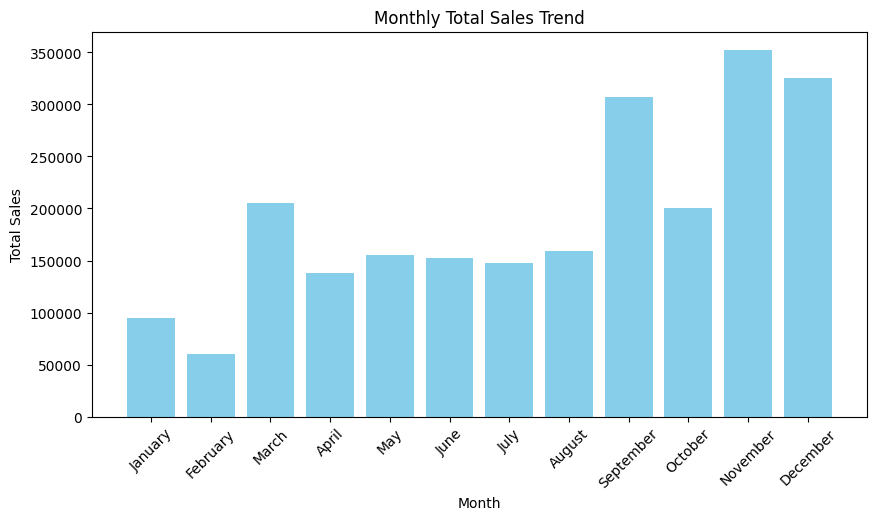

In [ ]:
import matplotlib.pyplot as plt

# Hitung total penjualan bulanan
df_monthly_sales = df.groupby(by=['month_num', 'month'], as_index=False)['sales'].sum()

# Buat grafik tren penjualan bulanan menggunakan matplotlib
plt.figure(figsize=(10,5))
plt.bar(df_monthly_sales['month'], df_monthly_sales['sales'], color='skyblue') # Mengubah warna bar menjadi 'skyblue'
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Total Sales Trend')
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

In [ ]:
import pandas as pd

URL = 'https://raw.githubusercontent.com/dataskillsboost/FinalProjectDA11/main/tokopaedi.csv'
df_new = pd.read_csv(URL)
display(df_new.head())

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,subcategory,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Berikut adalah informasi dasar dari DataFrame yang baru dimuat:

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  subcategory    9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  sales          9994 non-null   float64
 18  quantity

### Memvalidasi Output Gemini


Meskipun Gemini adalah alat yang canggih dan dapat menghasilkan kode yang terlihat meyakinkan, sangat penting untuk selalu memvalidasi output yang dihasilkannya.
Gemini adalah model bahasa, bukan seorang analis data yang sebenarnya. Kadang-kadang, kode yang dihasilkannya mungkin memiliki:
1. Kesalahan sintaksis kecil.
2. Logika yang tidak sepenuhnya sesuai dengan tujuan analisis Anda.
3. Output yang tidak sesuai dengan ekspektasi Anda berdasarkan pemahaman data.


Memvalidasi output memastikan bahwa kode yang Anda gunakan benar, efisien, dan menghasilkan hasil analisis yang akurat.

**Reasoning**:
Jelaskan praktik terbaik ketiga: Memecah tugas kompleks menjadi subtugas yang lebih kecil, jelaskan manfaat dari pendekatan ini. Setelah itu, subtask selesai.



## Memvalidasi output gemini



#### 1. Memeriksa Sintaks Kode
Langkah pertama adalah memeriksa sintaks kode yang dihasilkan oleh Gemini.
- **Secara Visual:** Bacalah kode baris per baris. Perhatikan detail kecil seperti tanda kurung, titik dua, indentasi, dan ejaan.
- **Menggunakan Syntax Highlighting:** Lingkungan pengembangan seperti Google Colab secara otomatis memberikan warna pada bagian-bagian kode (syntax highlighting). Ini membantu mengidentifikasi kesalahan sintaksis, misalnya kata kunci yang salah eja atau string yang tidak tertutup.
- **Menjalankan Kode:** Cara paling pasti untuk memeriksa sintaks adalah dengan mencoba menjalankan kodenya. Python akan memberikan pesan error yang spesifik jika ada kesalahan sintaksis.


#### 2. Memastikan Logika Kode Sesuai
Setelah sintaksisnya benar, Anda perlu memastikan bahwa logika kode melakukan apa yang Anda inginkan.
- **Tinjau Langkah-langkah:** Baca kode dan pahami setiap langkahnya. Apakah kode tersebut memuat data dengan benar? Apakah filter atau agregasi dilakukan pada kolom yang tepat? Apakah perhitungan yang dilakukan sudah benar?
- **Pahami Kode:** Jangan hanya menyalin dan menempel. Cobalah untuk memahami mengapa Gemini menghasilkan kode tersebut dan bagaimana cara kerjanya. Jika ada bagian yang tidak Anda pahami, cari dokumentasinya atau tanyakan kepada Gemini lagi untuk penjelasan.
- **Periksa Kondisi dan Loop:** Jika kode melibatkan kondisi (if/else) atau perulangan (for/while), pastikan logikanya mencakup semua skenario yang relevan dan berjalan sesuai harapan.

#Minitask

Tampilkan TOP 5 City selama 2016 dengan berdasarkan nilai profit yang paling tinggi. Tampilkan juga dengan bar diagram.

Berikut contoh pengerjaan data yang lain: https://drive.google.com/drive/folders/19sYNJ2HYmnDyho0pmOgsVh8zV8FvZtRT?usp=sharing
